# Parameter Tuning

Which conditions make a pair of rival campaigns divide a population most completely? Optuna (Bayesian optimisation) searches over the model parameters — both sides get identical values — minimising

$$(\text{left} - N/2)^2 + (\text{right} - N/2)^2 + \text{neutral}^2 + \text{mood changes}$$

which rewards an even left/right split, few neutral citizens, and stable allegiances. The objective value acts as a measure of how (un)polarised the population ends up: lower = more polarised.

In [1]:
import sys
sys.path.append('..')

import warnings

import matplotlib.pyplot as plt
import optuna
import seaborn as sns

from src import config
from src.model import simulate
from src.plot import draw_network
from src.tune import run_study

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore', category=optuna.exceptions.ExperimentalWarning)

C:\Users\madha\Desktop\FLAME University\Coursework\FSP PGDip (2023-24)\MATH231 Modeling for Social Sciences\final-project\code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
study = run_study(n_trials=500, seed=config.SEED)
print('Best parameters:', study.best_params)
print('Best objective value:', study.best_value)

Best parameters: {'ILR': 13, 'DLR': 12, 'PLR': 7.123573957505625, 'SM': 8.008469358522694, 'SD': 5.332734345170162, 'D': 9}
Best objective value: 698.0


## Search diagnostics

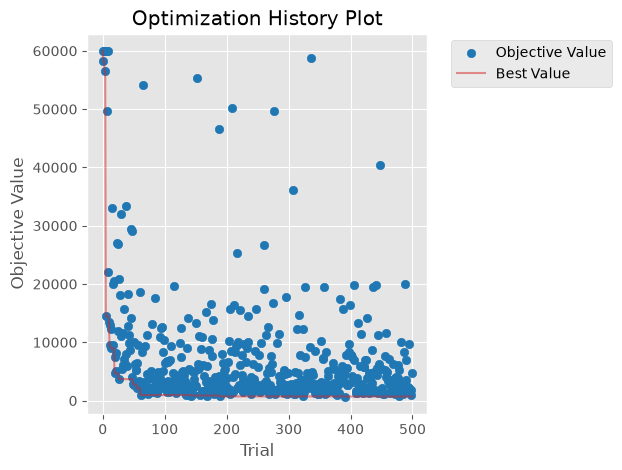

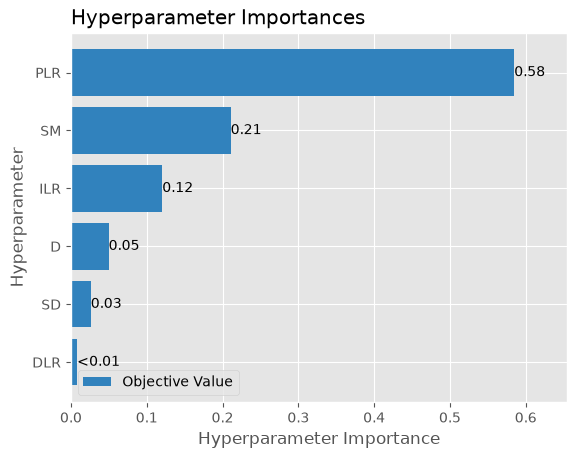

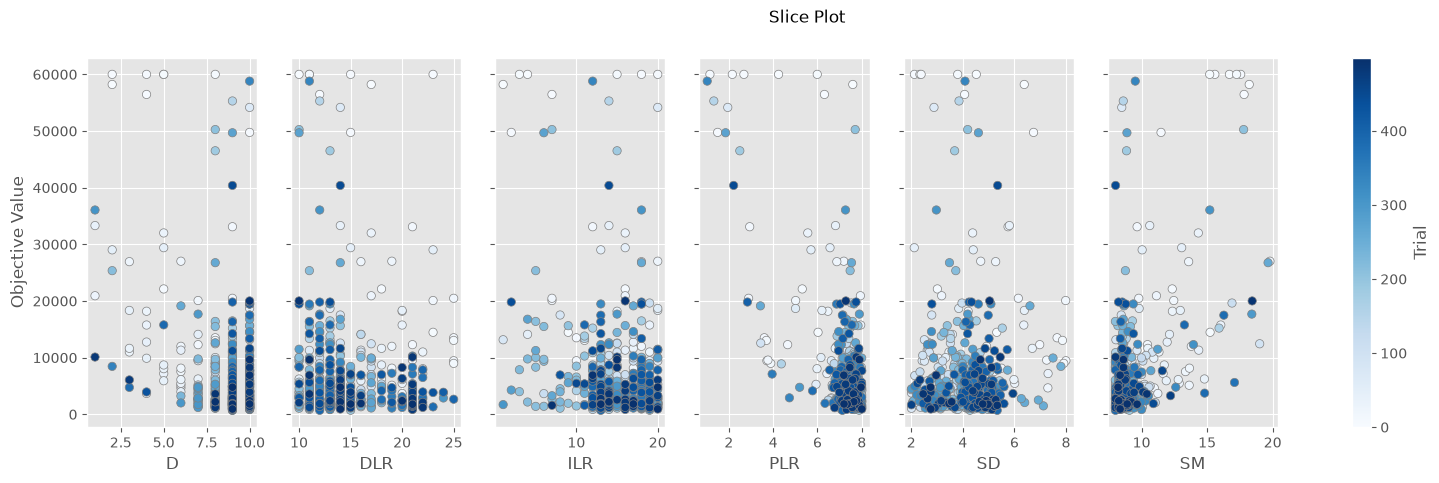

In [3]:
from optuna.visualization.matplotlib import (
    plot_optimization_history, plot_param_importances, plot_slice)

plot_optimization_history(study)
plt.show()
plot_param_importances(study)
plt.show()
plot_slice(study)
plt.show()

## Parameter relationships across all trials

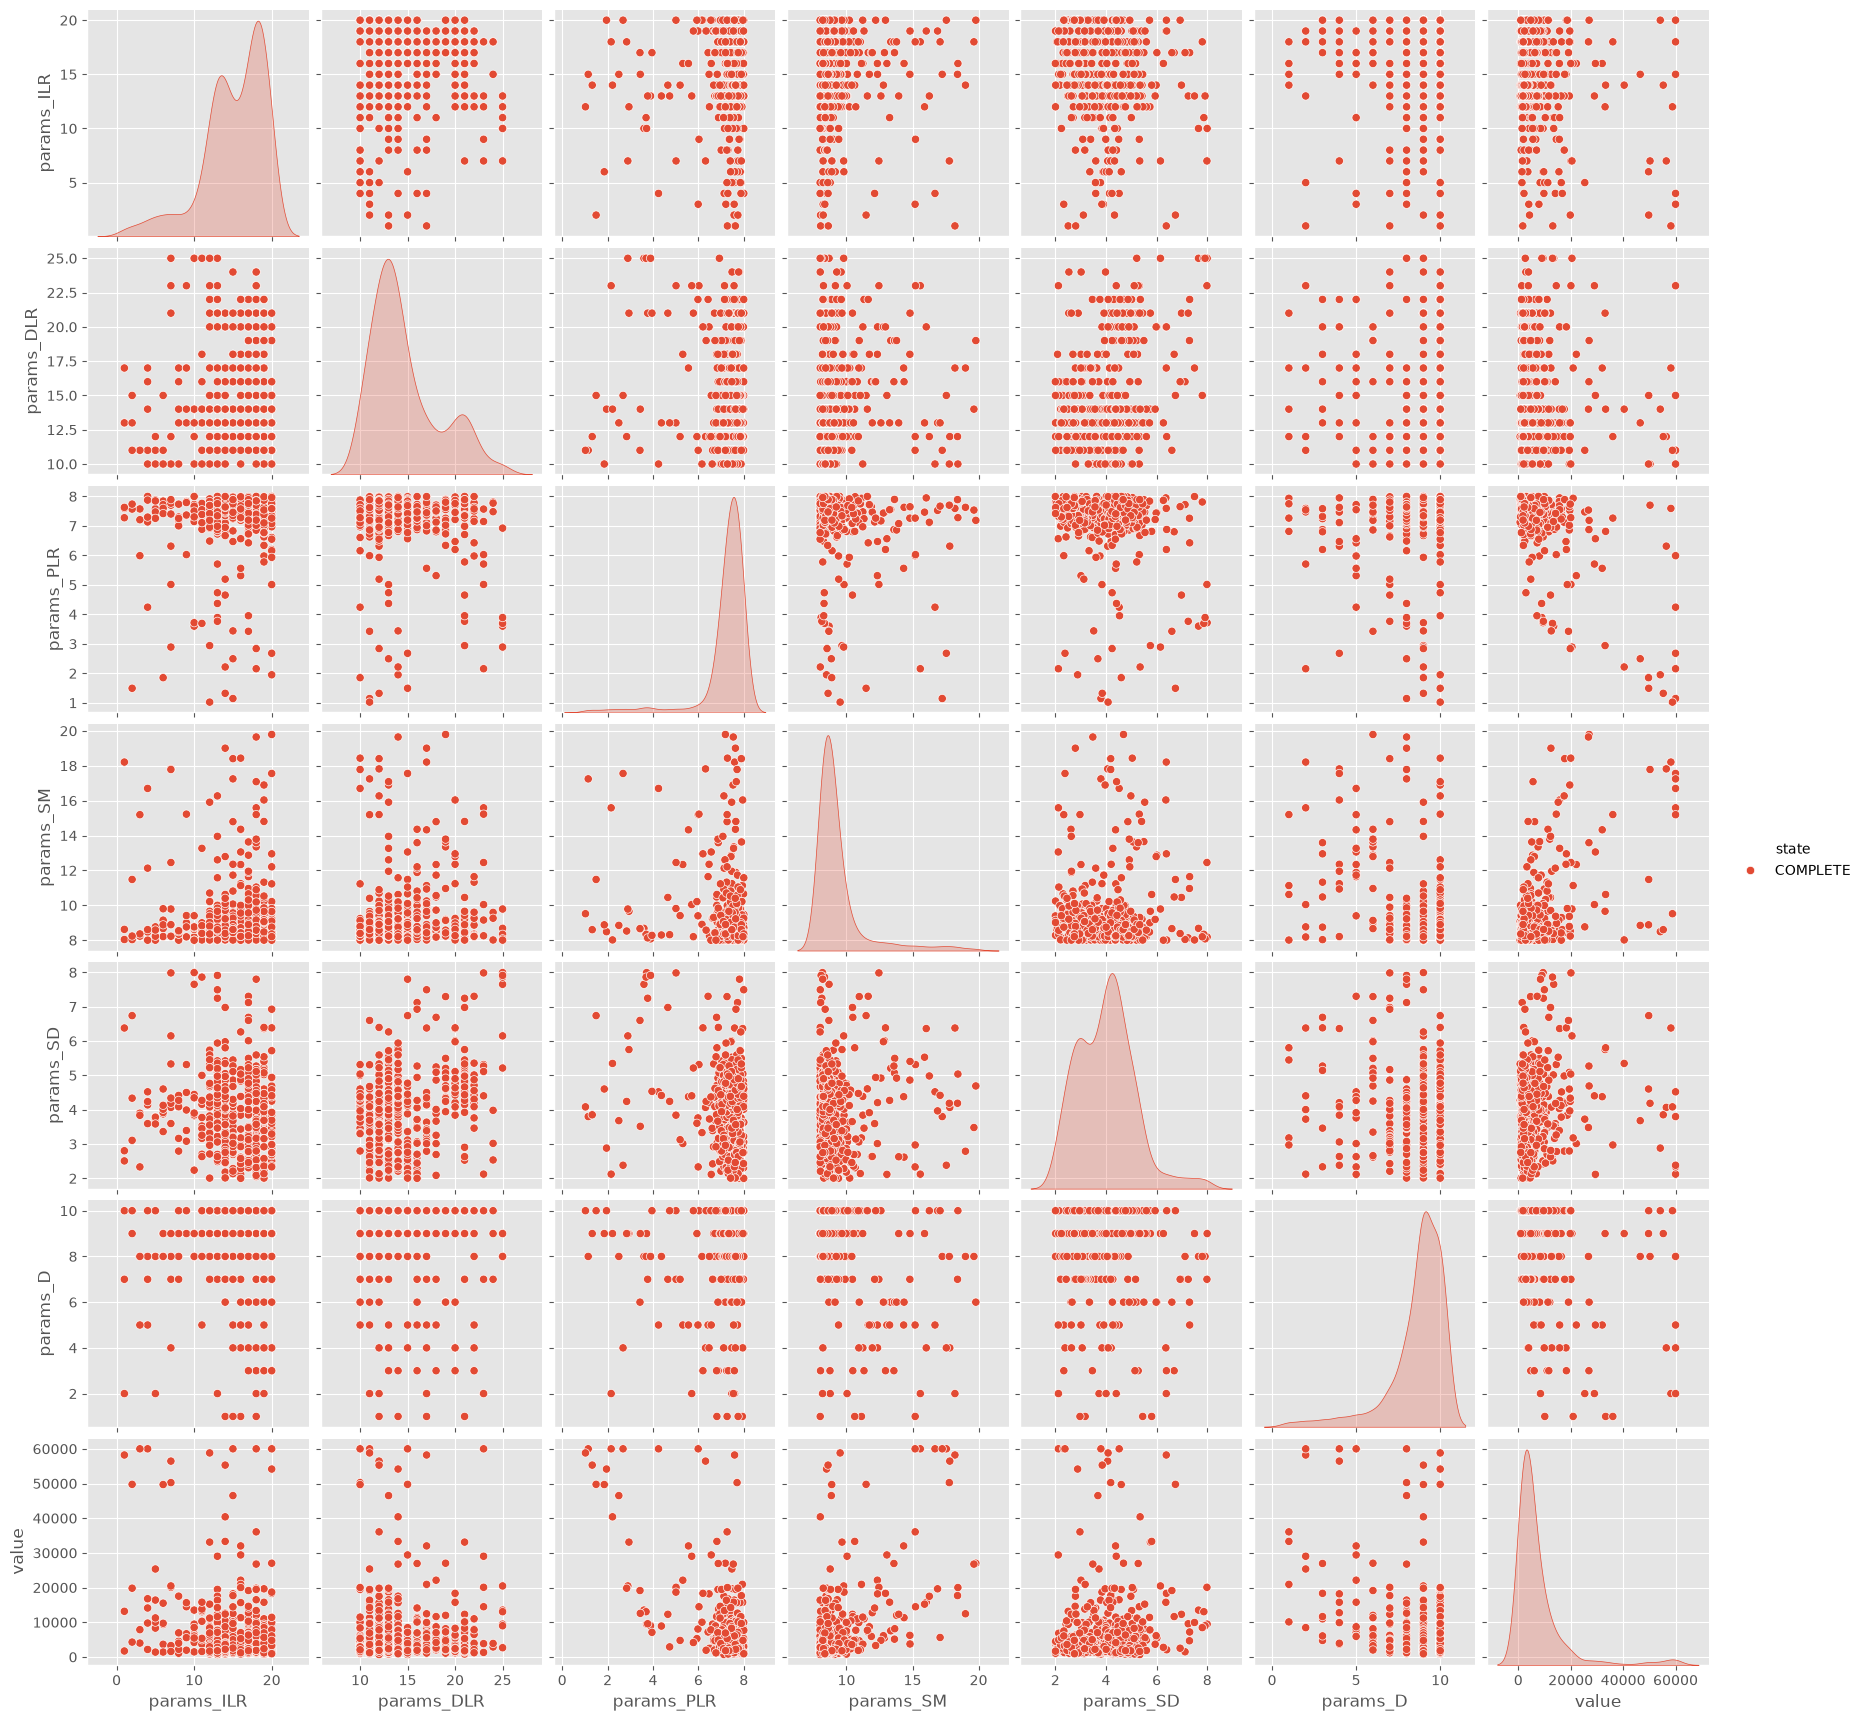

In [4]:
trials = study.trials_dataframe()
params = ['params_ILR', 'params_DLR', 'params_PLR', 'params_SM',
          'params_SD', 'params_D', 'value']

sns.pairplot(trials, vars=params, hue='state')
plt.show()

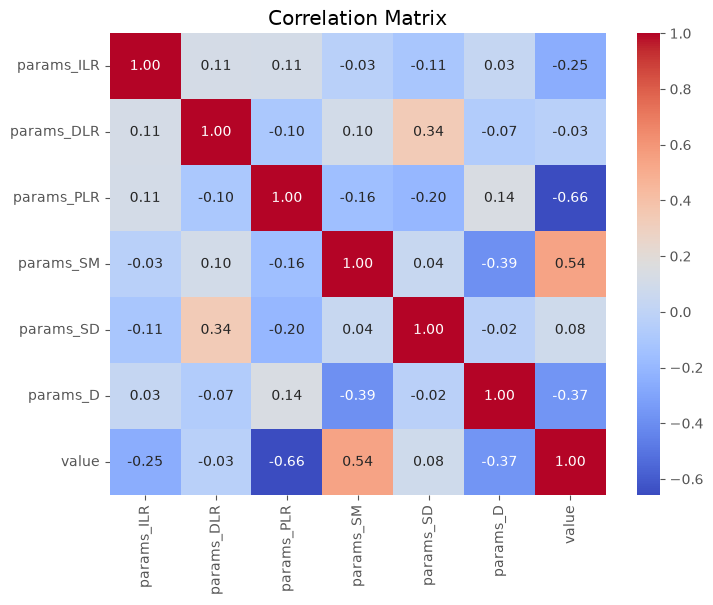

In [5]:
corr = trials[params].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## Reproducing the winning trial

Every trial is seeded (`seed = base seed + trial number`), so the exact run the objective scored can be recreated.

left=89 right=91 neutral=20 (mood changes: 96)


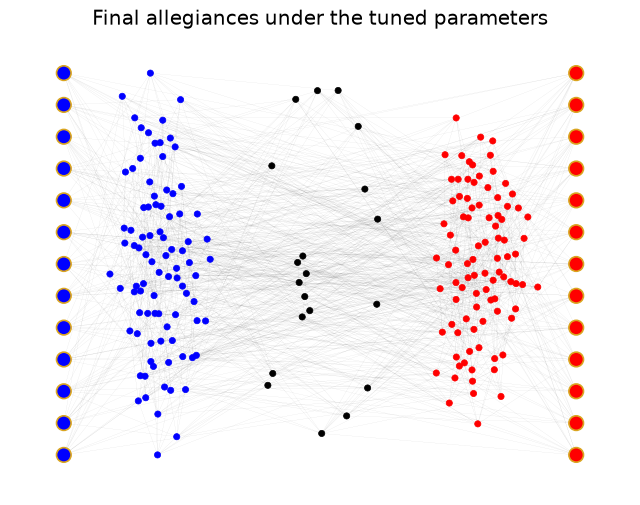

In [6]:
best = study.best_params
result = simulate(N=200, D=best['D'], IL=best['ILR'], IR=best['ILR'],
                  DL=best['DLR'], DR=best['DLR'],
                  PL=-best['PLR'], PR=best['PLR'],
                  SM=best['SM'], SD=best['SD'],
                  max_steps=config.TUNE_STEPS, early_stop=False,
                  seed=config.SEED + study.best_trial.number)
left, right, neutral = result.final_counts
print(f'left={left} right={right} neutral={neutral} '
      f'(mood changes: {result.mood_changes})')

draw_network(result.graph, 200, clustered=True, seed=0,
             title='Final allegiances under the tuned parameters')
plt.show()